In [1]:
#allow for autoreload of packages
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

import fresh
import recycle
import utils

In [3]:
n = 7

# FRESH

In [4]:
fr_str = {}

fr_str[0] = """
0.11
0.12	0.1
0.19	0.11	0.22
0.27	0.17	0.28	0.29
0.27	0.17	0.27	0.3	0.24
0.25	0.18	0.35	0.39	0.22	0.24
0.37	0.21	0.41	0.53	0.25	0.25	0.33"""

fr_str[1] = """
0.054
0.05	0.031
0.053	0.03	0.077
0.054	0.081	0.098	0.12
0.11	0.071	0.11	0.12	0.11
0.11	0.064	0.11	0.13	0.086	0.092
0.14	0.097	0.26	0.29	0.13	0.12	0.17"""

fr_str[2] = """
0.052
0.07	0.032
0.094	0.061	0.12
0.097	0.06	0.093	0.11
0.13	0.092	0.15	0.15	0.14
0.17	0.084	0.2	0.24	0.16	0.17
0.12	0.088	0.12	0.16	0.098	0.1	0.16"""

# transcribed from the saved opt_level=3 heatmap
fr_str[3] = """
0.043
0.066	0.036
0.075	0.052	0.088
0.13	0.088	0.19	0.2
0.12	0.064	0.15	0.14	0.13
0.13	0.06	0.15	0.18	0.091	0.11
0.17	0.12	0.21	0.21	0.16	0.1	0.21"""

fr = {opt: utils.create_df(s) for opt, s in fr_str.items()}

opt_level=0


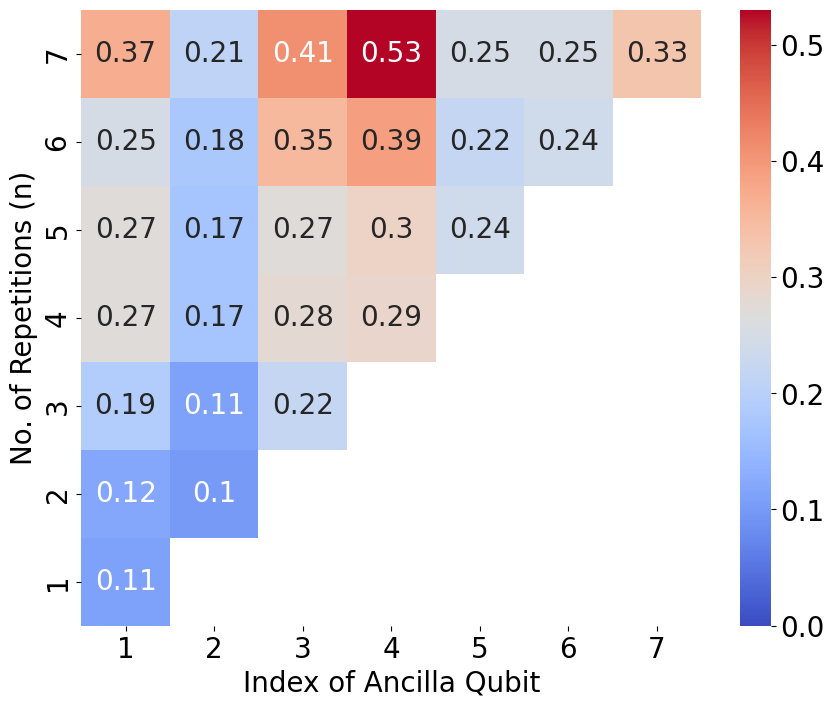

opt_level=1


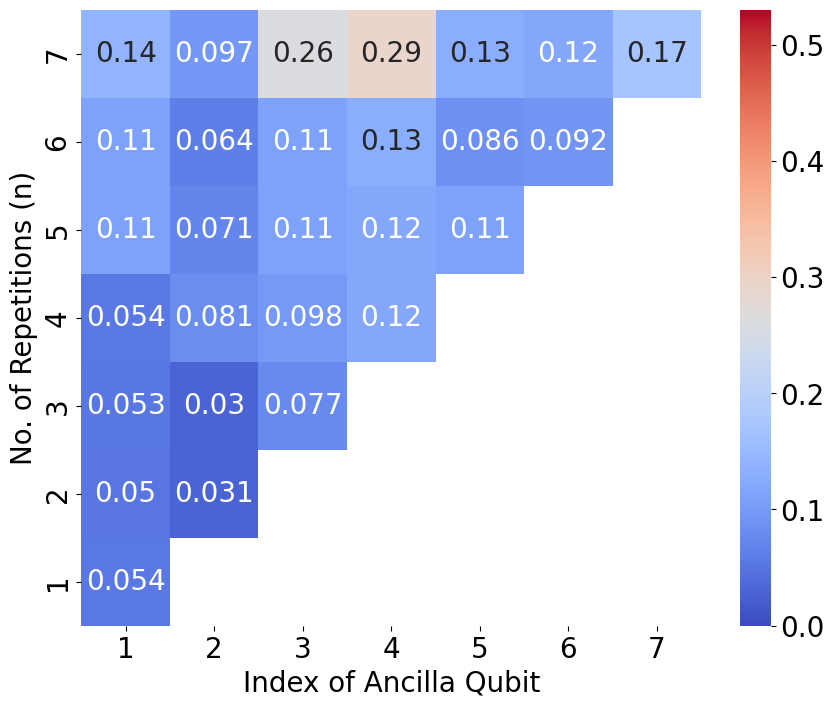

opt_level=2


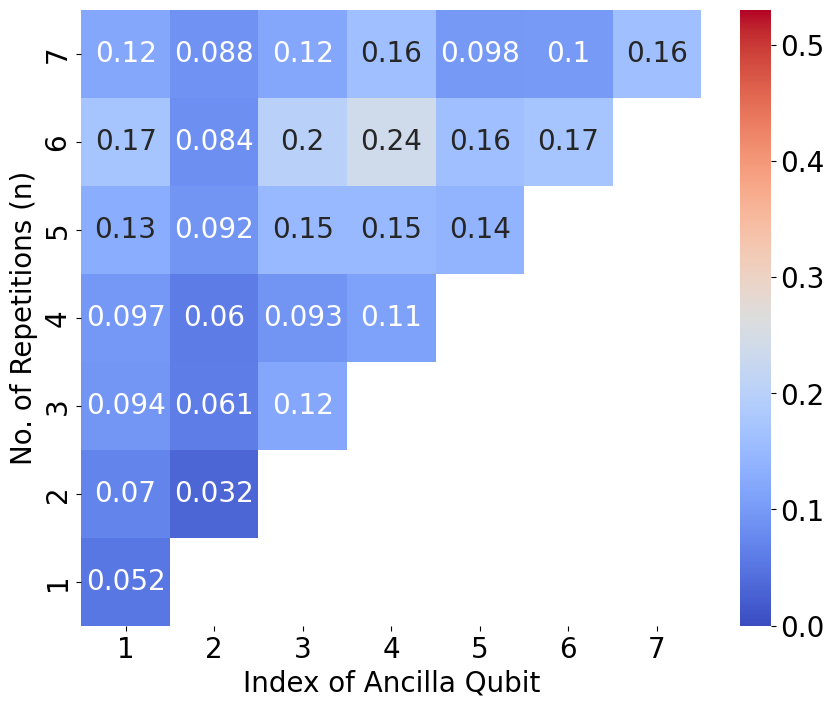

opt_level=3


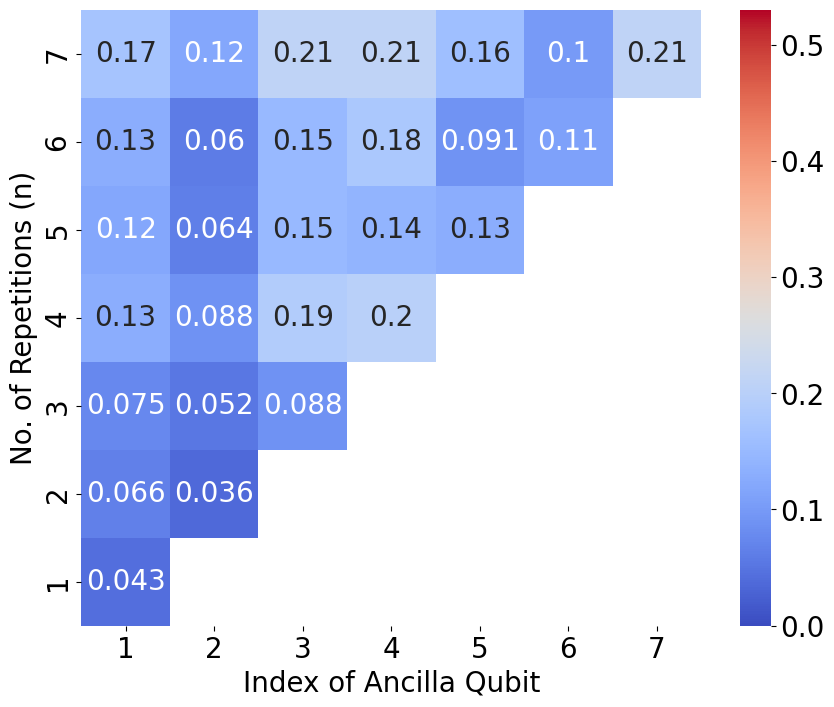

In [5]:
for opt in fr:
    print(f"opt_level={opt}")
    fresh.plot_heatmap(fr[opt], opt)

# RECYCLE

In [6]:
# P(ancilla = 1) for 1..n repetitions, as printed by the saved runs
re = {
    0: [0.06, 0.064, 0.066, 0.113, 0.135, 0.174, 0.172],
    1: [0.016, 0.03, 0.01, 0.022, 0.011, 0.014, 0.02],
    2: [0.011, 0.029, 0.01, 0.008, 0.063, 0.012, 0.026],
    3: [0.008, 0.01, 0.015, 0.031, 0.039, 0.016, 0.03],
}

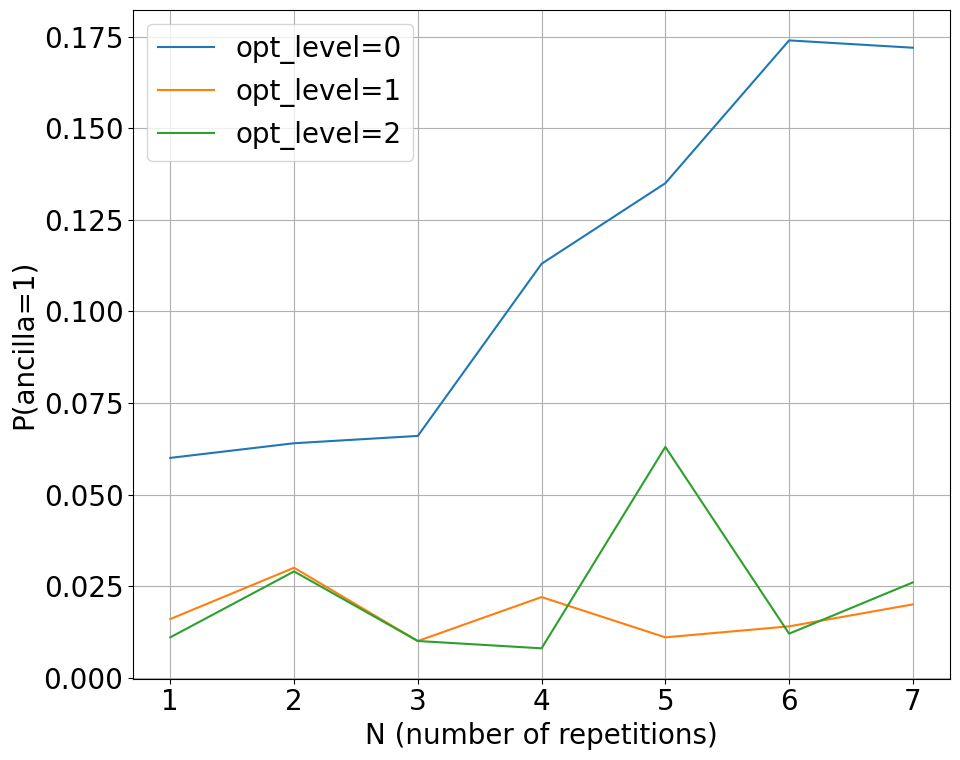

In [17]:
recycle.plot_all_results(re[0], re[1], re[2], n)

# Error rates

In [7]:
rows = []
for opt in fr:
    corre = recycle.corr_err(fr[opt], re[opt], n)                    # Eq. (4)
    rows.append({
        "opt_level": opt,
        "plaq_F Eq.12 (%)": fresh.plag_error_rate(fr[opt], n, window=True) * 100,
        "plaq_F Eq.6 (%)": fresh.plag_error_rate(fr[opt], n, window=False) * 100,
        "plaq_R Eq.8 (%)": recycle.plag_error_rate(corre, re[opt], n) * 100,
        "corre Eq.4 (%)": corre * 100,
    })

table = pd.DataFrame(rows).set_index("opt_level").round(2)
table

,plaq_F Eq.13 (%),plaq_F Eq.7 (%),plaq_R Eq.9 (%),corre Eq.5 (%)
opt_level,,,,
0,3.60,3.67,12.64,-1.80
1,1.77,1.93,4.28,-0.70
2,2.46,1.80,5.92,-0.94
3,2.41,2.78,8.11,-1.29
